In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
from pathlib import Path

# Root directory
ROOT_DIR = Path("D:/Projects/healthcare-xai-cost-prediction")

# Data paths - AP KA ACTUAL PATH
HOSP_DIR = ROOT_DIR / "data" / "raw" / "mimic-iv-clinical-database-demo-2.2" / "hosp"
ICU_DIR  = ROOT_DIR / "data" / "raw" / "mimic-iv-clinical-database-demo-2.2" / "icu"

# Verify paths exist
print(f"HOSP exists: {HOSP_DIR.exists()}")
print(f"ICU exists:  {ICU_DIR.exists()}")

# List files
print(f"\nHOSP files:")
for f in sorted(HOSP_DIR.glob("*.csv")):
    print(f"  {f.name}")

print(f"\nICU files:")
for f in sorted(ICU_DIR.glob("*.csv")):
    print(f"  {f.name}")

HOSP exists: True
ICU exists:  True

HOSP files:
  admissions.csv
  d_hcpcs.csv
  d_icd_diagnoses.csv
  d_icd_procedures.csv
  d_labitems.csv
  diagnoses_icd.csv
  drgcodes.csv
  emar.csv
  emar_detail.csv
  hcpcsevents.csv
  labevents.csv
  microbiologyevents.csv
  omr.csv
  patients.csv
  pharmacy.csv
  poe.csv
  poe_detail.csv
  prescriptions.csv
  procedures_icd.csv
  provider.csv
  services.csv
  transfers.csv

ICU files:
  caregiver.csv
  chartevents.csv
  d_items.csv
  datetimeevents.csv
  icustays.csv
  ingredientevents.csv
  inputevents.csv
  outputevents.csv
  procedureevents.csv


In [3]:
# HOSPITAL MODULE
patients      = pd.read_csv(HOSP_DIR / "patients.csv")
admissions    = pd.read_csv(HOSP_DIR / "admissions.csv")
diagnoses     = pd.read_csv(HOSP_DIR / "diagnoses_icd.csv")
procedures    = pd.read_csv(HOSP_DIR / "procedures_icd.csv")
prescriptions = pd.read_csv(HOSP_DIR / "prescriptions.csv")
labevents     = pd.read_csv(HOSP_DIR / "labevents.csv")
drgcodes      = pd.read_csv(HOSP_DIR / "drgcodes.csv")

# ICU MODULE
icustays      = pd.read_csv(ICU_DIR / "icustays.csv")
chartevents   = pd.read_csv(ICU_DIR / "chartevents.csv")

# Summary
tables = {
    "patients": patients,
    "admissions": admissions,
    "diagnoses": diagnoses,
    "procedures": procedures,
    "prescriptions": prescriptions,
    "labevents": labevents,
    "drgcodes": drgcodes,
    "icustays": icustays,
    "chartevents": chartevents
}

print(f"{'Table':<20} {'Rows':<10} {'Cols':<8} {'Columns (first 3)'}")
print("-"*70)
for name, df in tables.items():
    print(f"{name:<20} {df.shape[0]:<10} {df.shape[1]:<8} {list(df.columns[:3])}")

Table                Rows       Cols     Columns (first 3)
----------------------------------------------------------------------
patients             100        6        ['subject_id', 'gender', 'anchor_age']
admissions           275        16       ['subject_id', 'hadm_id', 'admittime']
diagnoses            4506       5        ['subject_id', 'hadm_id', 'seq_num']
procedures           722        6        ['subject_id', 'hadm_id', 'seq_num']
prescriptions        18087      21       ['subject_id', 'hadm_id', 'pharmacy_id']
labevents            107727     16       ['labevent_id', 'subject_id', 'hadm_id']
drgcodes             454        7        ['subject_id', 'hadm_id', 'drg_type']
icustays             140        8        ['subject_id', 'hadm_id', 'stay_id']
chartevents          668862     11       ['subject_id', 'hadm_id', 'stay_id']


In [4]:
print("PATIENTS TABLE")
print("="*50)
display(patients.head())
print(f"\nShape: {patients.shape}")
print(f"\nGender:\n{patients['gender'].value_counts()}")
print(f"\nAge Stats:\n{patients['anchor_age'].describe()}")
print(f"\nMissing:\n{patients.isnull().sum()}")

PATIENTS TABLE


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09



Shape: (100, 6)

Gender:
gender
M    57
F    43
Name: count, dtype: int64

Age Stats:
count    100.00000
mean      61.75000
std       16.16979
min       21.00000
25%       51.75000
50%       63.00000
75%       72.00000
max       91.00000
Name: anchor_age, dtype: float64

Missing:
subject_id            0
gender                0
anchor_age            0
anchor_year           0
anchor_year_group     0
dod                  69
dtype: int64


In [5]:
print("ADMISSIONS TABLE")
print("="*50)
display(admissions.head())

# Calculate Length of Stay
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])
admissions['length_of_stay'] = (
    admissions['dischtime'] - admissions['admittime']
).dt.total_seconds() / (24 * 3600)

print(f"\nLOS Stats:\n{admissions['length_of_stay'].describe()}")
print(f"\nAdmission Type:\n{admissions['admission_type'].value_counts()}")
print(f"\nInsurance:\n{admissions['insurance'].value_counts()}")

ADMISSIONS TABLE


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0



LOS Stats:
count    275.000000
mean       6.875530
std        6.733832
min        0.046528
25%        2.692014
50%        4.852778
75%        8.768403
max       44.927778
Name: length_of_stay, dtype: float64

Admission Type:
admission_type
EW EMER.                       104
OBSERVATION ADMIT               45
URGENT                          38
EU OBSERVATION                  30
SURGICAL SAME DAY ADMISSION     18
DIRECT EMER.                    15
ELECTIVE                        13
DIRECT OBSERVATION               7
AMBULATORY OBSERVATION           5
Name: count, dtype: int64

Insurance:
insurance
Other       149
Medicare    104
Medicaid     22
Name: count, dtype: int64


In [6]:
print("DRG CODES - COST DATA")
print("="*50)
display(drgcodes.head(10))
print(f"\nColumns: {drgcodes.columns.tolist()}")
print(f"\nDRG Type:\n{drgcodes['drg_type'].value_counts()}")
print(f"\nSeverity Stats:\n{drgcodes['drg_severity'].describe()}")
print(f"\nMortality Stats:\n{drgcodes['drg_mortality'].describe()}")

DRG CODES - COST DATA


,subject_id,hadm_id,drg_type,drg_code,description,drg_severity,drg_mortality
0,10004235,22187210,HCFA,864,FEVER,NaN,NaN
1,10026255,22059910,HCFA,180,RESPIRATORY NEOPLASMS W MCC,NaN,NaN
2,10032725,20611640,HCFA,54,NERVOUS SYSTEM NEOPLASMS W MCC,NaN,NaN
3,10005866,21636229,HCFA,393,OTHER DIGESTIVE SYSTEM DIAGNOSES W MCC,NaN,NaN
4,10008454,20291550,HCFA,956,"LIMB REATTACHMENT, HIP & FEMUR PROC FOR MULTIP...",NaN,NaN
5,10035631,24912093,HCFA,839,CHEMO W ACUTE LEUKEMIA AS SDX W/O CC/MCC,NaN,NaN
6,10005866,23514107,HCFA,388,G.I. OBSTRUCTION W MCC,NaN,NaN
7,10035631,21476294,HCFA,840,LYMPHOMA & NON-ACUTE LEUKEMIA W MCC,NaN,NaN
8,10018081,28861356,HCFA,345,MINOR SMALL & LARGE BOWEL PROCEDURES W CC,NaN,NaN
9,10015272,27993466,HCFA,176,PULMONARY EMBOLISM W/O MCC,NaN,NaN



Columns: ['subject_id', 'hadm_id', 'drg_type', 'drg_code', 'description', 'drg_severity', 'drg_mortality']

DRG Type:
drg_type
HCFA    233
APR     221
Name: count, dtype: int64

Severity Stats:
count    221.000000
mean       2.805430
std        0.896035
min        1.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        4.000000
Name: drg_severity, dtype: float64

Mortality Stats:
count    221.000000
mean       2.470588
std        1.055416
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        4.000000
Name: drg_mortality, dtype: float64


In [7]:
print("ICU STAYS")
print("="*50)
display(icustays.head())

icustays['intime']  = pd.to_datetime(icustays['intime'])
icustays['outtime'] = pd.to_datetime(icustays['outtime'])
icustays['icu_los'] = (
    icustays['outtime'] - icustays['intime']
).dt.total_seconds() / (24 * 3600)

print(f"\nICU LOS Stats:\n{icustays['icu_los'].describe()}")
print(f"\nCare Units:\n{icustays['first_careunit'].value_counts()}")

ICU STAYS


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106



ICU LOS Stats:
count    140.000000
mean       3.679379
std        3.896354
min        0.023727
25%        1.170663
50%        2.155093
75%        4.907749
max       20.528681
Name: icu_los, dtype: float64

Care Units:
first_careunit
Medical Intensive Care Unit (MICU)                  29
Surgical Intensive Care Unit (SICU)                 29
Cardiac Vascular Intensive Care Unit (CVICU)        25
Medical/Surgical Intensive Care Unit (MICU/SICU)    23
Trauma SICU (TSICU)                                 16
Coronary Care Unit (CCU)                            13
Neuro Surgical Intensive Care Unit (Neuro SICU)      3
Neuro Stepdown                                       1
Neuro Intermediate                                   1
Name: count, dtype: int64


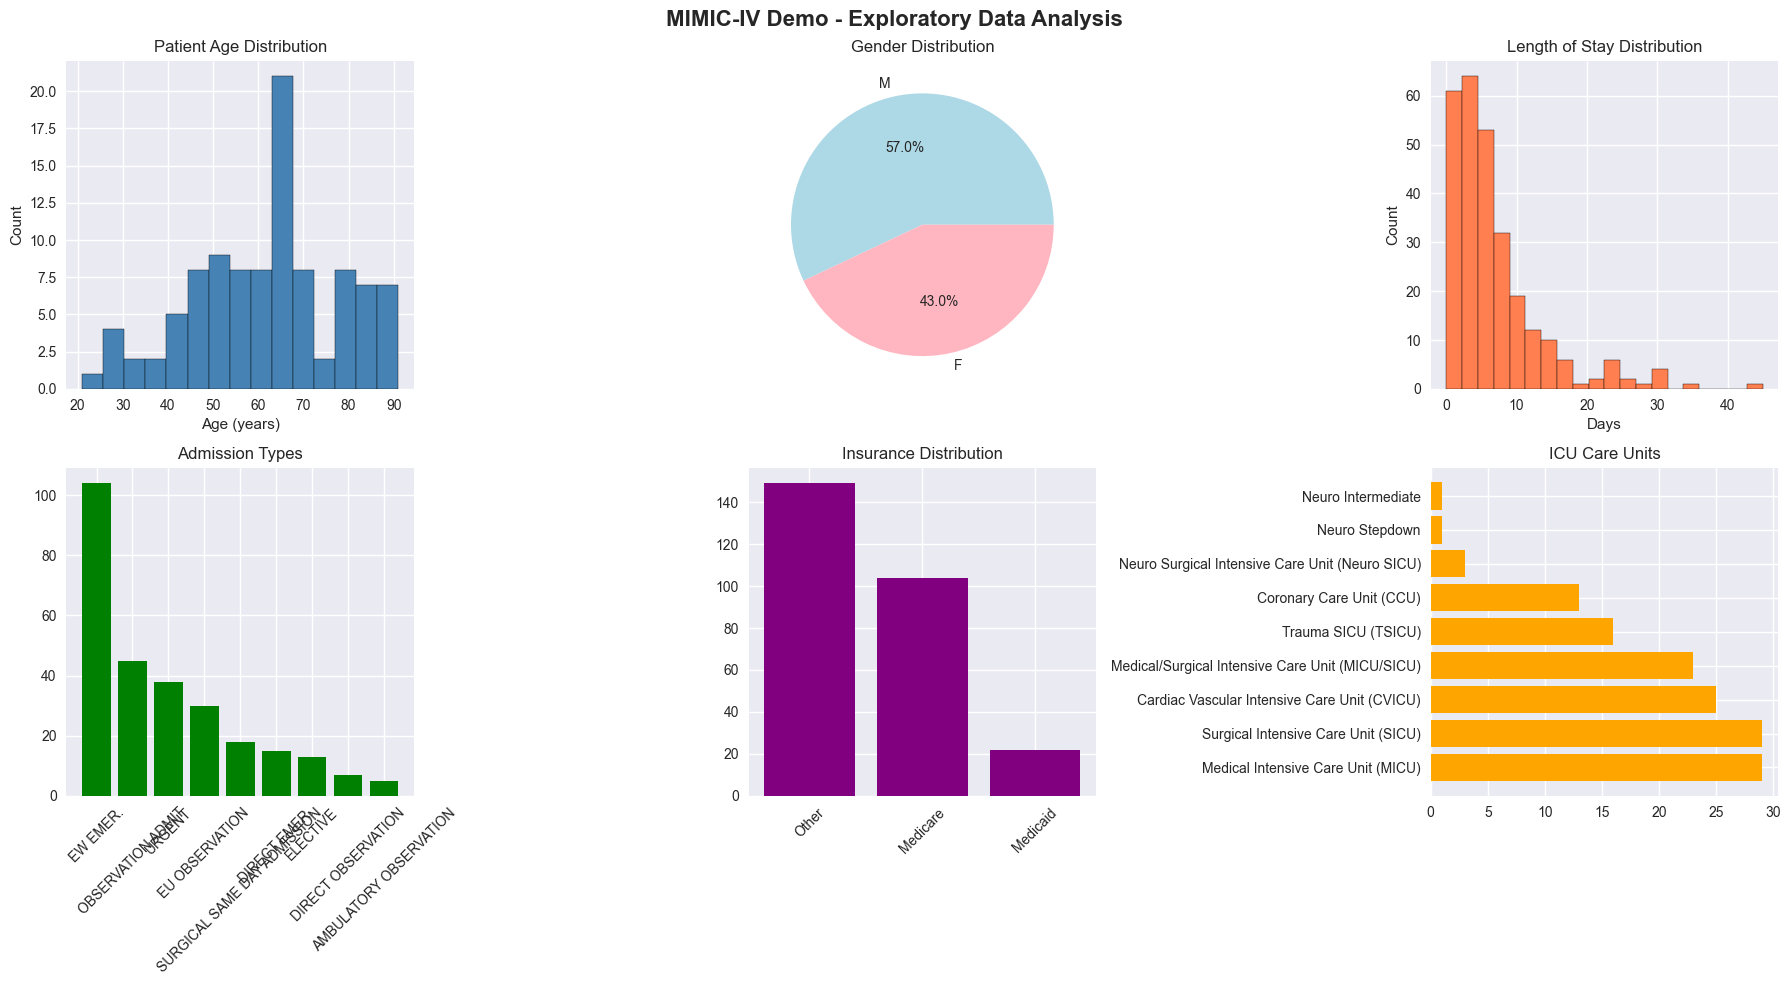

✅ Plot saved to reports/figures/


In [8]:
# Reports folder
REPORTS_DIR = ROOT_DIR / "reports" / "figures"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('MIMIC-IV Demo - Exploratory Data Analysis',
             fontsize=16, fontweight='bold')

# 1. Age Distribution
axes[0,0].hist(patients['anchor_age'].dropna(),
               bins=15, color='steelblue', edgecolor='black')
axes[0,0].set_title('Patient Age Distribution')
axes[0,0].set_xlabel('Age (years)')
axes[0,0].set_ylabel('Count')

# 2. Gender Pie
gender = patients['gender'].value_counts()
axes[0,1].pie(gender.values, labels=gender.index,
              autopct='%1.1f%%', colors=['lightblue','lightpink'])
axes[0,1].set_title('Gender Distribution')

# 3. LOS Distribution
los_clean = admissions['length_of_stay'].dropna()
los_clean = los_clean[los_clean > 0]
axes[0,2].hist(los_clean, bins=20, color='coral', edgecolor='black')
axes[0,2].set_title('Length of Stay Distribution')
axes[0,2].set_xlabel('Days')
axes[0,2].set_ylabel('Count')

# 4. Admission Type
adm = admissions['admission_type'].value_counts()
axes[1,0].bar(adm.index, adm.values, color='green')
axes[1,0].set_title('Admission Types')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Insurance
ins = admissions['insurance'].value_counts()
axes[1,1].bar(ins.index, ins.values, color='purple')
axes[1,1].set_title('Insurance Distribution')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. ICU Care Units
icu_units = icustays['first_careunit'].value_counts()
axes[1,2].barh(icu_units.index, icu_units.values, color='orange')
axes[1,2].set_title('ICU Care Units')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Plot saved to reports/figures/")

In [9]:
print("="*60)
print("📊 DATASET SUMMARY")
print("="*60)
print(f"✅ Total Patients:      {patients.shape[0]}")
print(f"✅ Total Admissions:    {admissions.shape[0]}")
print(f"✅ Total ICU Stays:     {icustays.shape[0]}")
print(f"✅ Total Diagnoses:     {diagnoses.shape[0]}")
print(f"✅ Total Prescriptions: {prescriptions.shape[0]}")
print(f"✅ Total Lab Events:    {labevents.shape[0]}")
print(f"\n📈 Avg LOS:  {admissions['length_of_stay'].mean():.2f} days")
print(f"📈 Max LOS:  {admissions['length_of_stay'].max():.2f} days")
print(f"📈 Avg ICU LOS: {icustays['icu_los'].mean():.2f} days")
print("\n✅ Notebook 01 Complete!")
print("▶ Next: Notebook 02 - Data Preprocessing")

📊 DATASET SUMMARY
✅ Total Patients:      100
✅ Total Admissions:    275
✅ Total ICU Stays:     140
✅ Total Diagnoses:     4506
✅ Total Prescriptions: 18087
✅ Total Lab Events:    107727

📈 Avg LOS:  6.88 days
📈 Max LOS:  44.93 days
📈 Avg ICU LOS: 3.68 days

✅ Notebook 01 Complete!
▶ Next: Notebook 02 - Data Preprocessing
